Train shape:  (436, 13)
Test shape:  (109, 13)
Mean of scaled train set:  [ 9.05239186e-17  8.71022164e-17 -7.94471522e-17]
Std of scaled train set:  [1. 1. 1.]
Epoch 0: Cost= 12346609757158.80
Epoch 100: Cost= 1945463905501.86
Epoch 200: Cost= 665635789050.06
Epoch 300: Cost= 493764301933.15
Epoch 400: Cost= 470274206190.92
Epoch 500: Cost= 466951282927.66
Epoch 600: Cost= 466437750005.34
Epoch 700: Cost= 466341520167.59
Epoch 800: Cost= 466317352509.65
Epoch 900: Cost= 466309399247.69
Manual RMSE: 977373.5130159932
Manual R²: 0.6998906693516538


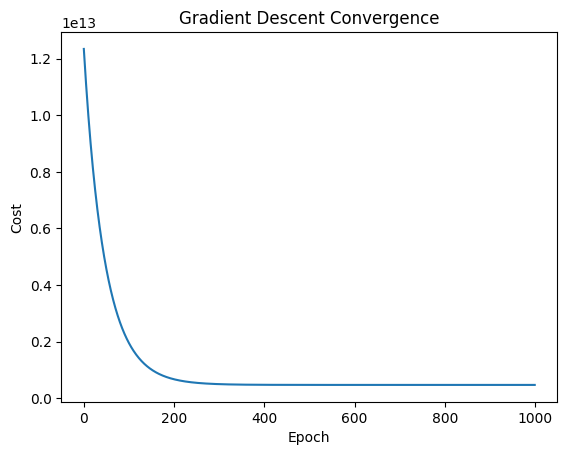

In [10]:
#from google.colab import files
#uploaded = files.upload()
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df=pd.read_csv('Housing.csv')
df=df.dropna()
df=pd.get_dummies(df,drop_first=True)
Q1=df['price'].quantile(0.25)
Q3=df['price'].quantile(0.75)
IQR=Q3-Q1
upper_b=Q3+1.5*IQR
df['price']=np.where(df['price']>upper_b,upper_b,df['price'])
X = df.drop('price', axis=1).values.astype(float)
y = df['price'].values.astype(float)
def train_test_split(X,y,test_size=0.2,random_state=42):
  np.random.seed(random_state)
  m=X.shape[0]
  indices=np.arange(m)
  np.random.shuffle(indices)
  test_count=int(m*test_size)
  test_indices=indices[:test_count]
  train_indices=indices[test_count:]
  X_train,X_test=X[train_indices],X[test_indices]
  y_train,y_test=y[train_indices],y[test_indices]
  return X_train,X_test,y_train,y_test
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=32)
print("Train shape: ",X_train.shape)
print("Test shape: ",X_test.shape)
def standardize(X_train,X_test):
  mu=X_train.mean(axis=0)
  sigma=X_train.std(axis=0)
  X_train_scaled=(X_train-mu)/sigma
  X_test_scaled=(X_test-mu)/sigma
  return X_train_scaled,X_test_scaled,mu,sigma
X_train_scaled,X_test_scaled,mu,sigma=standardize(X_train,X_test)
print("Mean of scaled train set: ", X_train_scaled.mean(axis=0)[:3])
print("Std of scaled train set: ", X_train_scaled.std(axis=0)[:3])
n_features=X_train_scaled.shape[1]
w=np.zeros(n_features)
b=0
def compute_cost(X,y,w,b):
  m=X.shape[0]
  y_pred=X.dot(w)+b
  cost=(1/(2*m))*np.sum((y_pred-y)**2)
  return cost
def compute_gradients(X,y,w,b):
  m=X.shape[0]
  y_pred=X.dot(w)+b
  error=y_pred-y
  dw=(1/m)*X.T.dot(error)
  db=(1/m)*np.sum(error)
  return dw,db
def gradient_descent(X,y,w,b,learning_rate,epochs):
  cost_history=[]
  for i in range(epochs):
    dw,db=compute_gradients(X,y,w,b)
    w=w-learning_rate*dw
    b=b-learning_rate*db
    cost=compute_cost(X,y,w,b)
    cost_history.append(cost)
    if i%100==0:
      print(f"Epoch {i}: Cost= {cost:.2f}")
  return w,b,cost_history
w, b, cost_history = gradient_descent(X_train_scaled, y_train, w, b, learning_rate=0.01, epochs=1000)
def predict(X,w,b):
  return X.dot(w)+b
def compute_rmse(y_true,y_pred):
  return np.sqrt(np.mean((y_true-y_pred)**2))
def compute_r2(y_true,y_pred):
  ss_res=np.sum((y_true-y_pred)**2)
  ss_tot=np.sum((y_true-y_true.mean())**2)
  return 1-(ss_res/ss_tot)
y_pred_test=predict(X_test_scaled,w,b)
rmse=compute_rmse(y_test,y_pred_test)
r2=compute_r2(y_test,y_pred_test)
print("Manual RMSE:", rmse)
print("Manual R²:", r2)
plt.plot(cost_history)
plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.title("Gradient Descent Convergence")
plt.show()
